# Holographic Cluster-State Synthesis — Unified Reproducibility Notebook

This notebook reproduces the corrected exclusive-family study for $D+R+\mathrm{SQR}$ and $D+R+\mathrm{CPSQR}$ in two connected branches:

1. **Full-target branch** — the original logical unitary $U_{\mathrm{target}} = \mathrm{SWAP}\cdot\mathrm{CZ}\cdot(H\otimes I)$ on $\{|g,0\rangle, |g,1\rangle, |e,0\rangle, |e,1\rangle\}$.
2. **Ground-sector follow-up** — the reduced transfer task $U_{\mathrm{joint}}(|g\rangle \otimes |\psi\rangle) \approx |g\rangle \otimes H_c |\psi\rangle$ on $\{|g,0\rangle, |g,1\rangle\}$, where $H_c$ is the logical cavity Hadamard.

It proceeds in eight stages:

1. **Setup** — imports and shared study utilities.
2. **User-Tunable Parameters** — configurable paths, evidence truncation, saved-figure selectors, and rerun toggles for the full-target, reduced-target, and primitive-diagnostic branches.
3. **Derived Objects** — load the saved summaries, artifacts, and benchmark bundles, then expose helpers for downstream cells.
4. **Target verification** — confirm $U_{\mathrm{target}} = \mathrm{SWAP}\cdot\mathrm{CZ}\cdot(H\otimes I)$ and show the logical target matrix.
5. **Full-target structured results** — summarize the saved full-target finalists and their physical-retention metrics.
6. **Active-subspace diagnostics** — inspect the bounded-support rule and the saved retention notes.
7. **Ground-sector follow-up** — compare the rescored full-target winners against the restricted-target refinements and re-generate the reduced-objective frontier plots.
8. **Benchmark and recommendation** — place the structured winners beside the validated GRAPE and primitive-level diagnostics, then summarize what changes between the two objectives.

By default, the notebook loads saved results from `data/` and `artifacts/`, including `corrected_scope_summary.json`, `ground_sector_followup_summary.json`, `grape_frontier_extension.json`, and `primitive_grape_diagnostics.json`. Commented rerun cells are included for the expensive full-target search, the reduced-target follow-up, and the primitive-diagnostics branch so the notebook remains fast by default while still exposing the full reproduction path.

---
## 1. Setup, Parameters, and Derived Objects

In [1]:
import importlib
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

SCRIPTS_DIR = Path.cwd() if Path.cwd().name == "scripts" else Path.cwd() / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print("Importing study utilities ...")
import common as common_module
importlib.reload(common_module)
from common import (
    TARGET_UNITARY,
    GROUND_SECTOR_TARGET_UNITARY,
    GROUND_SECTOR_LABELS,
    LOGICAL_LABELS,
    OMEGA_Q,
    OMEGA_C,
    ALPHA,
    CHI,
    CHI_PRIME,
    KERR,
    load_json,
    DATA_DIR,
    FIG_DIR,
    jax_available,
    resolve_grape_engine,
 )

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
TWO_PI = 2.0 * np.pi

print("Import complete.")

Importing study utilities ...
Import complete.


### User-Tunable Parameters

This cell exposes the saved-result paths, evidence truncation, plotting behavior, and rerun toggles for the full-target study, the ground-sector follow-up, the GRAPE reference, and the primitive diagnostics. Change values here, then re-run the derived-objects cell immediately below before running the rest of the notebook.

In [2]:
NOTEBOOK_CONFIG = {
    "summary_filename": "corrected_scope_summary.json",
    "what_changed_filename": "what_changed_summary.md",
    "ground_followup_summary_filename": "ground_sector_followup_summary.json",
    "ground_followup_candidates_filename": "ground_sector_followup_candidates.csv",
    "ground_best_sqr_artifact": "ground_sector_best_sqr.json",
    "ground_best_cpsqr_artifact": "ground_sector_best_cpsqr.json",
    "ground_block_figure": "ground_sector_block_summary.png",
    "ground_scatter_figure": "ground_sector_objective_scatter.png",
    "grape_frontier_filename": "grape_frontier_extension.json",
    "primitive_diagnostics_filename": "primitive_grape_diagnostics.json",
    "primitive_arrays_filename": "primitive_grape_diagnostics_arrays.npz",
    "primitive_summary_figure": "primitive_grape_summary.png",
    "primitive_wigner_figure": "primitive_grape_wigner.png",
    "grape_reference_selector": "best-replay",
    "grape_engine_preference": "auto",
    "primitive_engine_preference": "auto",
    "families": ("drsqr", "drcpsqr"),
    "final_n_cav": 12,
    "validation_n_cav": (10, 12, 14),
    "target_fidelity": 0.99,
    "ground_target_threshold": 0.99,
    "leakage_reference": 0.01,
    "ground_refine_maxiter": 16,
    "primitive_seeds": (17, 42, 73),
    "primitive_maxiter": 200,
    "save_figures": True,
    "rerun_search": False,
    "rerun_figure_only": False,
    "rerun_ground_followup": False,
    "rerun_ground_followup_skip_refine": False,
    "rerun_primitive_diagnostics": False,
}

print("User-tunable parameters")
for key, value in NOTEBOOK_CONFIG.items():
    print(f"  {key}: {value}")

User-tunable parameters
  summary_filename: corrected_scope_summary.json
  what_changed_filename: what_changed_summary.md
  ground_followup_summary_filename: ground_sector_followup_summary.json
  ground_followup_candidates_filename: ground_sector_followup_candidates.csv
  ground_best_sqr_artifact: ground_sector_best_sqr.json
  ground_best_cpsqr_artifact: ground_sector_best_cpsqr.json
  ground_block_figure: ground_sector_block_summary.png
  ground_scatter_figure: ground_sector_objective_scatter.png
  grape_frontier_filename: grape_frontier_extension.json
  primitive_diagnostics_filename: primitive_grape_diagnostics.json
  primitive_arrays_filename: primitive_grape_diagnostics_arrays.npz
  primitive_summary_figure: primitive_grape_summary.png
  primitive_wigner_figure: primitive_grape_wigner.png
  grape_reference_selector: best-replay
  grape_engine_preference: auto
  primitive_engine_preference: auto
  families: ('drsqr', 'drcpsqr')
  final_n_cav: 12
  validation_n_cav: (10, 12, 14)
  t

### Derived Objects

This cell resolves the saved summary paths from the tunable parameters above, loads the saved artifacts, and builds the reusable objects used by the rest of the notebook. Re-run it after changing the parameter cell.

In [3]:
CORRECTED_SUMMARY_PATH = DATA_DIR / NOTEBOOK_CONFIG["summary_filename"]
WHAT_CHANGED_PATH = DATA_DIR / NOTEBOOK_CONFIG["what_changed_filename"]
GROUND_FOLLOWUP_PATH = DATA_DIR / NOTEBOOK_CONFIG["ground_followup_summary_filename"]
GROUND_FOLLOWUP_CSV_PATH = DATA_DIR / NOTEBOOK_CONFIG["ground_followup_candidates_filename"]
GRAPE_FRONTIER_PATH = DATA_DIR / NOTEBOOK_CONFIG["grape_frontier_filename"]
PRIMITIVE_DIAGNOSTICS_PATH = DATA_DIR / NOTEBOOK_CONFIG["primitive_diagnostics_filename"]
ARTIFACT_DIR = DATA_DIR.parent / "artifacts"
GROUND_SQR_ARTIFACT_PATH = ARTIFACT_DIR / NOTEBOOK_CONFIG["ground_best_sqr_artifact"]
GROUND_CPSQR_ARTIFACT_PATH = ARTIFACT_DIR / NOTEBOOK_CONFIG["ground_best_cpsqr_artifact"]
PRIMITIVE_ARRAYS_PATH = ARTIFACT_DIR / NOTEBOOK_CONFIG["primitive_arrays_filename"]
GROUND_BLOCK_FIG_PATH = FIG_DIR / NOTEBOOK_CONFIG["ground_block_figure"]
GROUND_SCATTER_FIG_PATH = FIG_DIR / NOTEBOOK_CONFIG["ground_scatter_figure"]
PRIMITIVE_SUMMARY_FIG_PATH = FIG_DIR / NOTEBOOK_CONFIG["primitive_summary_figure"]
PRIMITIVE_WIGNER_FIG_PATH = FIG_DIR / NOTEBOOK_CONFIG["primitive_wigner_figure"]

corrected = load_json(CORRECTED_SUMMARY_PATH)
ground_followup = load_json(GROUND_FOLLOWUP_PATH)
ground_best_sqr_artifact = load_json(GROUND_SQR_ARTIFACT_PATH)
ground_best_cpsqr_artifact = load_json(GROUND_CPSQR_ARTIFACT_PATH)
grape_frontier = load_json(GRAPE_FRONTIER_PATH)
primitive_diagnostics = load_json(PRIMITIVE_DIAGNOSTICS_PATH)
active_rule = corrected["active_subspace_definition"]
preferred_grape_engine = resolve_grape_engine(NOTEBOOK_CONFIG["grape_engine_preference"])
preferred_primitive_engine = resolve_grape_engine(NOTEBOOK_CONFIG["primitive_engine_preference"])

def by_n_cav(candidate, n_cav):
    return candidate["physical"]["by_n_cav"][str(n_cav)]

def family_outcome(family_key):
    for bucket, status in (
        ("retained_candidates", "retained"),
        ("low_confidence_candidates", "low-confidence"),
        ("discarded_candidates", "discarded"),
    ):
        candidate = corrected.get(bucket, {}).get(family_key)
        if candidate is not None:
            payload = dict(candidate)
            payload["_status"] = status
            return payload
    raise KeyError(f"No candidate recorded for family {family_key!r}")

def select_grape_reference(frontier_payload, selector="best-replay"):
    complete_rows = [
        row for row in frontier_payload.values()
        if isinstance(row, dict) and row.get("status") == "complete"
    ]
    if not complete_rows:
        raise KeyError("No complete GRAPE frontier entries found.")
    if selector == "best-replay":
        return max(complete_rows, key=lambda row: float(row["best_replay_fidelity"]))
    raise ValueError(f"Unsupported GRAPE selector {selector!r}")

def describe_grape_engine(row):
    requested = row.get("engine_requested", NOTEBOOK_CONFIG["grape_engine_preference"])
    resolved = row.get("engine_resolved", "not-recorded")
    available = row.get("jax_available", jax_available())
    return f"requested={requested}, resolved={resolved}, jax_available={available}"

def ground_family_outcome(family_key, role):
    return ground_followup["family_outcomes"][family_key][role]

def ground_candidates(family_key, source):
    rows = [
        row for row in ground_followup[f"{source}_candidates"]
        if row["family_key"] == family_key
    ]
    return sorted(rows, key=lambda row: int(row["blocks"]))

def sequence_duration_ns(sequence_payload):
    return 1e9 * sum(float(step["duration"]) for step in sequence_payload)

prelim_sqr = corrected["preliminary_best"]["drsqr"]
prelim_cpsqr = corrected["preliminary_best"]["drcpsqr"]
final_sqr = family_outcome("drsqr")
final_cpsqr = family_outcome("drcpsqr")
ground_baseline_sqr = ground_candidates("drsqr", source="baseline_rescored")
ground_baseline_cpsqr = ground_candidates("drcpsqr", source="baseline_rescored")
ground_refined_sqr = ground_candidates("drsqr", source="ground_refined")
ground_refined_cpsqr = ground_candidates("drcpsqr", source="ground_refined")
ground_best_sqr = ground_family_outcome("drsqr", "best_absolute")
ground_best_cpsqr = ground_family_outcome("drcpsqr", "best_absolute")
ground_min_depth_sqr = ground_family_outcome("drsqr", "minimum_depth_above_threshold")
ground_min_depth_cpsqr = ground_family_outcome("drcpsqr", "minimum_depth_above_threshold")
ground_cross_best = ground_followup["cross_family_summary"]["best_absolute"]
primitive_sqr = primitive_diagnostics["results"]["sqr"]
primitive_cpsqr = primitive_diagnostics["results"]["cpsqr"]
grape_reference = select_grape_reference(
    grape_frontier,
    selector=NOTEBOOK_CONFIG["grape_reference_selector"],
)

print("Physical parameters")
print(f"  omega_c / 2pi = {OMEGA_C / TWO_PI / 1e9:.3f} GHz")
print(f"  omega_q / 2pi = {OMEGA_Q / TWO_PI / 1e9:.3f} GHz")
print(f"  alpha   / 2pi = {ALPHA / TWO_PI / 1e6:.1f} MHz")
print(f"  chi     / 2pi = {CHI / TWO_PI / 1e6:.3f} MHz")
print(f"  chi'    / 2pi = {CHI_PRIME / TWO_PI / 1e3:.1f} kHz")
print(f"  Kerr    / 2pi = {KERR / TWO_PI / 1e3:.1f} kHz")
print()
print("Loaded study artifacts")
print(f"  full-target summary       = {CORRECTED_SUMMARY_PATH.name}")
print(f"  change summary           = {WHAT_CHANGED_PATH.name}")
print(f"  ground follow-up summary = {GROUND_FOLLOWUP_PATH.name}")
print(f"  ground follow-up table   = {GROUND_FOLLOWUP_CSV_PATH.name}")
print(f"  ground best SQR artifact = {GROUND_SQR_ARTIFACT_PATH.name}")
print(f"  ground best CPSQR artifact = {GROUND_CPSQR_ARTIFACT_PATH.name}")
print(f"  GRAPE frontier           = {GRAPE_FRONTIER_PATH.name}")
print(f"  primitive summary        = {PRIMITIVE_DIAGNOSTICS_PATH.name}")
print(f"  primitive arrays         = {PRIMITIVE_ARRAYS_PATH.name}")
print(f"  finalist evidence        = N_cav = {NOTEBOOK_CONFIG['final_n_cav']}")
print(f"  validation set           = {NOTEBOOK_CONFIG['validation_n_cav']}")
print(f"  families                 = {NOTEBOOK_CONFIG['families']}")
print()
print("Current saved ground-sector headline")
print(f"  cross-family best        = {ground_cross_best['family_label']} | blocks={ground_cross_best['blocks']} | order={ground_cross_best['order_label']}")
print(f"  restricted fidelity      = {ground_cross_best['n12_ground_fidelity']:.6f}")
print(f"  outside-target leakage   = {ground_cross_best['outside_target_leakage_worst']:.6f}")
print()
print("Current saved GRAPE reference")
print(f"  selector                 = {NOTEBOOK_CONFIG['grape_reference_selector']}")
print(f"  duration_ns              = {grape_reference['duration_ns']}")
print(f"  replay fidelity          = {grape_reference['best_replay_fidelity']:.6f}")
print(f"  open fidelity            = {grape_reference['open_process']['process_fidelity']:.6f}")
print(f"  engine metadata          = {describe_grape_engine(grape_reference)}")
print(f"  preferred rerun          = {preferred_grape_engine} (jax_available={jax_available()})")
print(f"  primitive rerun          = {preferred_primitive_engine} (seeds={NOTEBOOK_CONFIG['primitive_seeds']}, maxiter={NOTEBOOK_CONFIG['primitive_maxiter']})")
print()
print("Active-subspace rule")
print(f"  threshold      = {active_rule['threshold']}")
print(f"  capture_target = {active_rule['capture_target']}")
print(f"  rule           = {active_rule['rule']}")

Physical parameters
  omega_c / 2pi = 5.241 GHz
  omega_q / 2pi = 6.150 GHz
  alpha   / 2pi = -255.0 MHz
  chi     / 2pi = -2.840 MHz
  chi'    / 2pi = -21.0 kHz
  Kerr    / 2pi = -28.0 kHz

Loaded study artifacts
  full-target summary       = corrected_scope_summary.json
  change summary           = what_changed_summary.md
  ground follow-up summary = ground_sector_followup_summary.json
  ground follow-up table   = ground_sector_followup_candidates.csv
  ground best SQR artifact = ground_sector_best_sqr.json
  ground best CPSQR artifact = ground_sector_best_cpsqr.json
  GRAPE frontier           = grape_frontier_extension.json
  primitive summary        = primitive_grape_diagnostics.json
  primitive arrays         = primitive_grape_diagnostics_arrays.npz
  finalist evidence        = N_cav = 12
  validation set           = (10, 12, 14)
  families                 = ('drsqr', 'drcpsqr')

Current saved ground-sector headline
  cross-family best        = D + R + CPSQR | blocks=4 | order=RDC

---
## 2. Target Unitary Verification

The logical target is $U_{\mathrm{target}} = \mathrm{SWAP}\cdot\mathrm{CZ}\cdot(H\otimes I)$  
in the basis $\{|g,0\rangle, |g,1\rangle, |e,0\rangle, |e,1\rangle\}$.

Target unitary from make_target("cluster", n_match=1):
Basis order: ('|g,0>', '|g,1>', '|e,0>', '|e,1>')

[[ 0.7071  0.      0.7071  0.    ]
 [ 0.7071  0.     -0.7071  0.    ]
 [ 0.      0.7071  0.      0.7071]
 [ 0.     -0.7071  0.      0.7071]]

|Tr(U_analytic† · U_factory)| / 4 = 1.000000  (should be 1.000000)


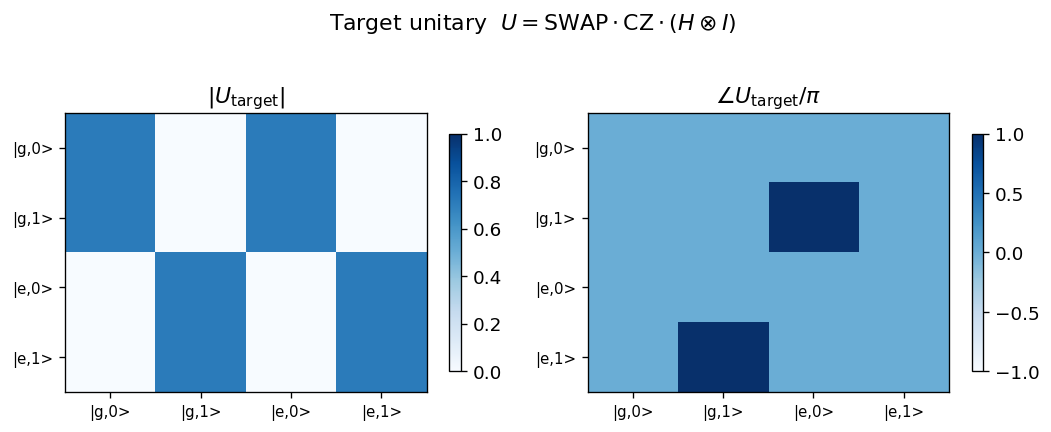

Saved to figures/target_unitary.pdf


In [22]:
# Display the target matrix from the framework factory
print('Target unitary from make_target("cluster", n_match=1):')
print('Basis order:', LOGICAL_LABELS)
print()
np.set_printoptions(precision=4, suppress=True)
print(np.round(TARGET_UNITARY.real, 4))

# Construct the target analytically and verify it matches the factory
SWAP = np.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], dtype=complex)
CZ = np.diag([1.0, 1.0, 1.0, -1.0]).astype(complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
I2 = np.eye(2, dtype=complex)
HI = np.kron(H, I2)
U_analytic = SWAP @ CZ @ HI

overlap = np.abs(np.trace(U_analytic.conj().T @ TARGET_UNITARY)) / 4.0
print()
print(f'|Tr(U_analytic† · U_factory)| / 4 = {overlap:.6f}  (should be 1.000000)')
assert overlap > 0.9999, 'Mismatch between analytic and factory target!'

# Visualise the target as an absolute-value matrix plot
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (mat, title) in zip(
    axes,
    [
        (np.abs(TARGET_UNITARY), r'$|U_{\mathrm{target}}|$'),
        (np.angle(TARGET_UNITARY) / np.pi, r'$\angle U_{\mathrm{target}} / \pi$'),
    ],
):
    im = ax.imshow(
        mat,
        cmap='Blues',
        vmin=0 if '|' in title else -1,
        vmax=1 if '|' in title else 1,
        aspect='auto',
    )
    ax.set_xticks(range(4))
    ax.set_xticklabels(LOGICAL_LABELS, fontsize=9)
    ax.set_yticks(range(4))
    ax.set_yticklabels(LOGICAL_LABELS, fontsize=9)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)

fig.suptitle('Target unitary  $U = \\mathrm{SWAP}\\cdot\\mathrm{CZ}\\cdot(H\\otimes I)$', y=1.02)
fig.tight_layout()
if NOTEBOOK_CONFIG['save_figures']:
    plt.savefig('../figures/target_unitary.pdf', bbox_inches='tight')
plt.show()
if NOTEBOOK_CONFIG['save_figures']:
    print('Saved to figures/target_unitary.pdf')

---
## 3. Full-Target Structured Results

This load-saved cell summarizes the best coarse-screen and final physically refined full-target finalists. The section is controlled by `summary_filename`, `final_n_cav`, `validation_n_cav`, `target_fidelity`, `leakage_reference`, and `save_figures` from the tunable-parameter cell.

Best coarse-screen candidates
  D + R + SQR     : drsqr_blk5_a4_ordRDS_RDS_lv0-1-2-3_blk5_t4
    ideal fidelity at N_cav=4 = 0.999287
    levels                  = [0, 1, 2, 3]
    total time              = 6180 ns
  D + R + CPSQR   : drcpsqr_blk5_a4_ordDCPR_DCPR_lv0-1-2-3_blk5_t4
    ideal fidelity at N_cav=4 = 0.998508
    levels                  = [0, 1, 2, 3]
    total time              = 1445 ns

Final physically refined outcome
  D + R + SQR status   : retained
    best F(N_cav=12)   = 0.999635
  D + R + CPSQR status : retained
    best F(N_cav=12)   = 0.997492

D + R + SQR  [retained]
  F(10)  = 0.999635
  F(12)  = 0.999635
  F(14)  = 0.999635
  leakage_worst(12) = 0.000777
  active support at N_cav=12 = 0..3
  touches truncation boundary = False

D + R + CPSQR  [retained]
  F(10)  = 0.997492
  F(12)  = 0.997492
  F(14)  = 0.997492
  leakage_worst(12) = 0.005423
  active support at N_cav=12 = 0..5
  touches truncation boundary = False



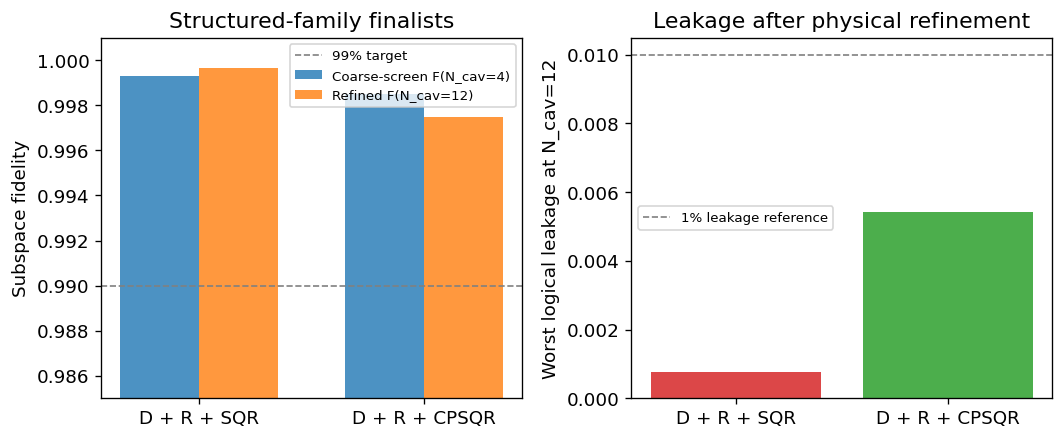

Saved to figures/notebook_corrected_summary.pdf


In [23]:
def candidate_row(label, candidate):
    f10 = by_n_cav(candidate, 10)
    f12 = by_n_cav(candidate, 12)
    f14 = by_n_cav(candidate, 14)
    active12 = f12['active_subspace']['candidate_active_levels']
    return {
        'label': label,
        'status': candidate['_status'],
        'F10': f10['fidelity'],
        'F12': f12['fidelity'],
        'F14': f14['fidelity'],
        'leak12': f12['leakage_worst'],
        'active12': active12,
        'touches_boundary_12': f12['active_subspace']['touches_truncation_boundary'],
    }

rows = [
    candidate_row("D + R + SQR", final_sqr),
    candidate_row("D + R + CPSQR", final_cpsqr),
]

print("Best coarse-screen candidates")
print(f"  D + R + SQR     : {prelim_sqr['case_id']}")
print(f"    ideal fidelity at N_cav=4 = {prelim_sqr['fidelity']:.6f}")
print(f"    levels                  = {prelim_sqr['levels']}")
print(f"    total time              = {prelim_sqr['summary']['total_duration_ns']:.0f} ns")
print(f"  D + R + CPSQR   : {prelim_cpsqr['case_id']}")
print(f"    ideal fidelity at N_cav=4 = {prelim_cpsqr['fidelity']:.6f}")
print(f"    levels                  = {prelim_cpsqr['levels']}")
print(f"    total time              = {prelim_cpsqr['summary']['total_duration_ns']:.0f} ns")

print()
print("Final physically refined outcome")
print(f"  D + R + SQR status   : {final_sqr['_status']}")
print(f"    best F(N_cav=12)   = {by_n_cav(final_sqr, 12)['fidelity']:.6f}")
print(f"  D + R + CPSQR status : {final_cpsqr['_status']}")
print(f"    best F(N_cav=12)   = {by_n_cav(final_cpsqr, 12)['fidelity']:.6f}")

print()
for row in rows:
    active_label = f"{row['active12'][0]}..{row['active12'][-1]}"
    print(f"{row['label']}  [{row['status']}]")
    print(f"  F(10)  = {row['F10']:.6f}")
    print(f"  F(12)  = {row['F12']:.6f}")
    print(f"  F(14)  = {row['F14']:.6f}")
    print(f"  leakage_worst(12) = {row['leak12']:.6f}")
    print(f"  active support at N_cav=12 = {active_label}")
    print(f"  touches truncation boundary = {row['touches_boundary_12']}")
    print()

labels = [row['label'] for row in rows]
prelim_f = [prelim_sqr['fidelity'], prelim_cpsqr['fidelity']]
final_f12 = [rows[0]['F12'], rows[1]['F12']]
leak12 = [rows[0]['leak12'], rows[1]['leak12']]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
x = np.arange(len(labels))
w = 0.35
axes[0].bar(x - w / 2, prelim_f, w, label='Coarse-screen F(N_cav=4)', color='C0', alpha=0.8)
axes[0].bar(x + w / 2, final_f12, w, label='Refined F(N_cav=12)', color='C1', alpha=0.8)
axes[0].axhline(NOTEBOOK_CONFIG['target_fidelity'], color='gray', ls='--', lw=1, label='99% target')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0.985, 1.001)
axes[0].set_ylabel('Subspace fidelity')
axes[0].set_title('Structured-family finalists')
axes[0].legend(fontsize=8)

axes[1].bar(labels, leak12, color=['C3', 'C2'], alpha=0.85)
axes[1].axhline(NOTEBOOK_CONFIG['leakage_reference'], color='gray', ls='--', lw=1, label='1% leakage reference')
axes[1].set_ylabel('Worst logical leakage at N_cav=12')
axes[1].set_title('Leakage after physical refinement')
axes[1].legend(fontsize=8)

fig.tight_layout()
if NOTEBOOK_CONFIG['save_figures']:
    plt.savefig('../figures/notebook_corrected_summary.pdf', bbox_inches='tight')
plt.show()
if NOTEBOOK_CONFIG['save_figures']:
    print('Saved to figures/notebook_corrected_summary.pdf')

### Re-Run With Current Parameters

The cell below is intentionally commented out. Uncomment it only if you want to regenerate the design-space outputs using the current notebook parameters rather than loading the saved summary.

In [ ]:
# --- Re-run with current parameters ---
# from subprocess import run
# 
# script_args = [sys.executable, str(SCRIPTS_DIR / 'run_design_space_study.py')]
# if NOTEBOOK_CONFIG['rerun_figure_only'] and '--skip-search' not in script_args:
#     script_args.append('--skip-search')
# if NOTEBOOK_CONFIG['rerun_search']:#     run(script_args, check=True, cwd=SCRIPTS_DIR)
# else:
#     print("Set NOTEBOOK_CONFIG['rerun_search'] = True to enable the expensive rerun.")

---
## 4. Active-Subspace Diagnostics

This load-saved cell reports the bounded-support rule, the retention notes attached to each finalist, the per-input active cavity support, and the short study-change summary. It depends on the same loaded summary objects constructed in the derived-objects cell.

In [24]:
print('Active-subspace definition')
for key, value in corrected['active_subspace_definition'].items():
    print(f'  {key}: {value}')

print()
print('Structured-family outcomes at N_cav = 12')
for label, candidate in [('D + R + SQR', final_sqr), ('D + R + CPSQR', final_cpsqr)]:
    active = by_n_cav(candidate, NOTEBOOK_CONFIG['final_n_cav'])['active_subspace']
    print(label)
    print(f"  candidate active levels : {active['candidate_active_levels']}")
    print(f"  worst captured pop.     : {active['candidate_worst_captured_population']:.6f}")
    print(f"  touches boundary        : {active['touches_truncation_boundary']}")
    print()

for label, candidate in [('D + R + SQR', final_sqr), ('D + R + CPSQR', final_cpsqr)]:
    print(f'Retention notes: {label}')
    for note in candidate.get('retention_notes', []):
        print(f'  - {note}')
    print()

for label, candidate in [('D + R + SQR', final_sqr), ('D + R + CPSQR', final_cpsqr)]:
    print(f'Per-input active support for {label} at N_cav = 12')
    per_input = by_n_cav(candidate, NOTEBOOK_CONFIG['final_n_cav'])['active_subspace']['per_input']
    for input_label, payload in per_input.items():
        levels = payload['active_levels']
        print(f"  {input_label:>6} -> active levels {levels[0]}..{levels[-1]}, worst captured population {payload['worst_captured_population']:.6f}")
    print()

print('What changed in the corrected rerun')
print('-' * 40)
print(WHAT_CHANGED_PATH.read_text())

Active-subspace definition
  threshold: 0.001
  capture_target: 0.999
  rule: For each candidate and each logical input, sample the full sequence gate-by-gate with intermediate fractional steps. Define the active cavity subspace as the set of Fock levels whose peak population is at least 1e-3, then expand that set until the worst instantaneous captured population is at least 99.9%.
  candidate_reporting: Report per-input active levels and the candidate-wide union at N_cav = 10, 12, 14.

Structured-family outcomes at N_cav = 12
D + R + SQR
  candidate active levels : [0, 1, 2, 3]
  worst captured pop.     : 0.999309
  touches boundary        : False

D + R + CPSQR
  candidate active levels : [0, 1, 2, 3, 4, 5]
  worst captured pop.     : 0.999189
  touches boundary        : False

Retention notes: D + R + SQR

Retention notes: D + R + CPSQR

Per-input active support for D + R + SQR at N_cav = 12
   |g,0> -> active levels 0..3, worst captured population 0.999459
   |g,1> -> active levels

---
## 5. Ground-Sector Follow-Up

This load-saved cell reproduces the reduced-objective follow-up from `ground_sector_followup_summary.json` and the saved best-candidate artifacts. It compares the old full-target winners after rescoring against the local restricted-target refinements, identifies the minimum depth above the $0.99$ ground-sector threshold in each family, and regenerates the block-summary and objective-mismatch plots from the saved summary data. The section is controlled by `ground_followup_summary_filename`, `ground_followup_candidates_filename`, `ground_best_sqr_artifact`, `ground_best_cpsqr_artifact`, `ground_target_threshold`, `ground_refine_maxiter`, `save_figures`, and the two ground-follow-up rerun toggles from the parameter cell.

Ground-sector target
  basis order = ('|g,0>', '|g,1>')
[[ 0.7071  0.7071]
 [ 0.7071 -0.7071]]

Saved full-target winner rescored: D + R + SQR
  blocks / order / levels = 5 / RDS / [0, 1, 2, 3]
  full-target fidelity     = 0.999635
  ground fidelity          = 0.499201
  ancilla excitation worst = 0.999843
  outside-target leakage   = 0.999997

Saved full-target winner rescored: D + R + CPSQR
  blocks / order / levels = 5 / DRCP / [1, 2]
  full-target fidelity     = 0.997492
  ground fidelity          = 0.498720
  ancilla excitation worst = 0.997676
  outside-target leakage   = 0.999902

Restricted-target SQR outcome
  best absolute            = blocks 5 | order RDS | levels [0, 1, 2, 3]
  restricted fidelity      = 0.999926
  full-target fidelity     = 0.367514
  outside-target leakage   = 0.000177
  artifact duration        = 6180.0 ns
  minimum depth above 0.99 = 3 blocks | order RDS | F_ground = 0.999745

Restricted-target CPSQR outcome
  best absolute            = blocks 4 | order

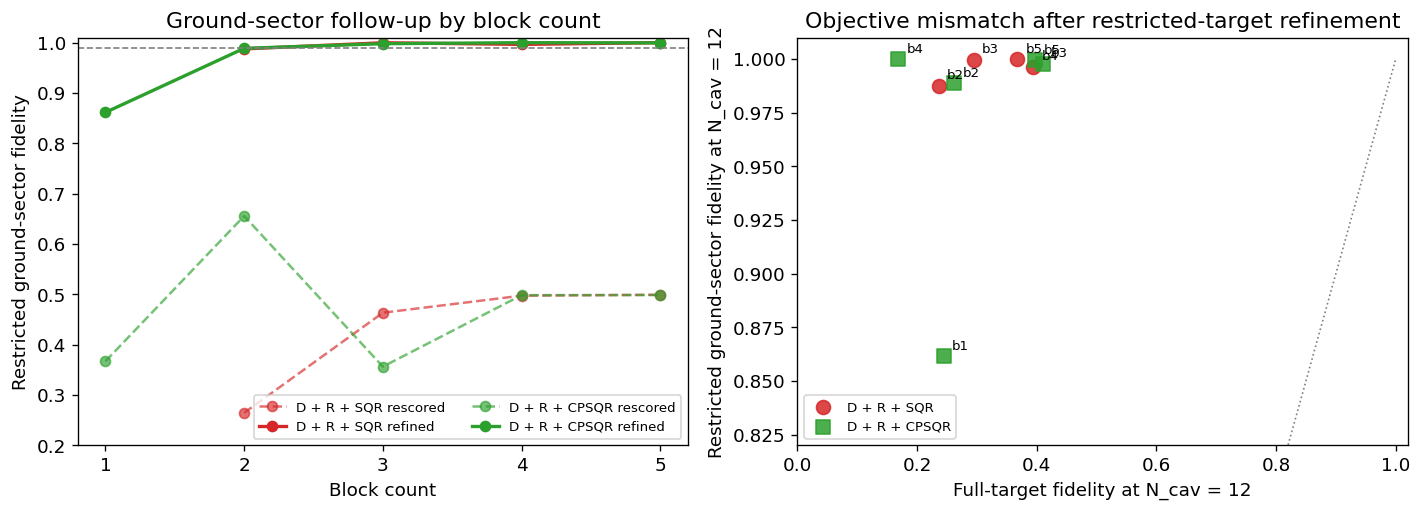

Saved to figures/notebook_ground_sector_followup.pdf


In [4]:
print("Ground-sector target")
print(f"  basis order = {GROUND_SECTOR_LABELS}")
print(np.round(GROUND_SECTOR_TARGET_UNITARY.real, 4))
print()

baseline_old_sqr = max(ground_baseline_sqr, key=lambda row: row["n12_full_target_fidelity"])
baseline_old_cpsqr = max(ground_baseline_cpsqr, key=lambda row: row["n12_full_target_fidelity"])

def print_ground_baseline(label, payload):
    print(f"Saved full-target winner rescored: {label}")
    print(f"  blocks / order / levels = {payload['blocks']} / {payload['order_label']} / {payload['levels']}")
    print(f"  full-target fidelity     = {payload['n12_full_target_fidelity']:.6f}")
    print(f"  ground fidelity          = {payload['n12_ground_fidelity']:.6f}")
    print(f"  ancilla excitation worst = {payload['ancilla_excitation_worst']:.6f}")
    print(f"  outside-target leakage   = {payload['outside_target_leakage_worst']:.6f}")
    print()

def print_ground_outcome(label, best_payload, min_depth_payload, artifact_payload):
    print(label)
    print(f"  best absolute            = blocks {best_payload['blocks']} | order {best_payload['order_label']} | levels {best_payload['levels']}")
    print(f"  restricted fidelity      = {best_payload['n12_ground_fidelity']:.6f}")
    print(f"  full-target fidelity     = {best_payload['n12_full_target_fidelity']:.6f}")
    print(f"  outside-target leakage   = {best_payload['outside_target_leakage_worst']:.6f}")
    print(f"  artifact duration        = {sequence_duration_ns(artifact_payload['sequence']):.1f} ns")
    print(f"  minimum depth above 0.99 = {min_depth_payload['blocks']} blocks | order {min_depth_payload['order_label']} | F_ground = {min_depth_payload['n12_ground_fidelity']:.6f}")
    print()

print_ground_baseline("D + R + SQR", baseline_old_sqr)
print_ground_baseline("D + R + CPSQR", baseline_old_cpsqr)
print_ground_outcome("Restricted-target SQR outcome", ground_best_sqr, ground_min_depth_sqr, ground_best_sqr_artifact)
print_ground_outcome("Restricted-target CPSQR outcome", ground_best_cpsqr, ground_min_depth_cpsqr, ground_best_cpsqr_artifact)
print("Cross-family reduced-objective winner")
print(f"  family / blocks / order = {ground_cross_best['family_label']} / {ground_cross_best['blocks']} / {ground_cross_best['order_label']}")
print(f"  restricted fidelity     = {ground_cross_best['n12_ground_fidelity']:.6f}")
print(f"  outside-target leakage  = {ground_cross_best['outside_target_leakage_worst']:.6f}")
print()
print("Saved reduced-objective artifacts")
print(f"  summary      = {GROUND_FOLLOWUP_PATH.name}")
print(f"  candidates   = {GROUND_FOLLOWUP_CSV_PATH.name}")
print(f"  best SQR     = {GROUND_SQR_ARTIFACT_PATH.name}")
print(f"  best CPSQR   = {GROUND_CPSQR_ARTIFACT_PATH.name}")
print(f"  block figure = {GROUND_BLOCK_FIG_PATH.name}")
print(f"  scatter      = {GROUND_SCATTER_FIG_PATH.name}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for family_label, base_rows, refined_rows, color in [
    ("D + R + SQR", ground_baseline_sqr, ground_refined_sqr, "C3"),
    ("D + R + CPSQR", ground_baseline_cpsqr, ground_refined_cpsqr, "C2"),
]:
    base_blocks = [row["blocks"] for row in base_rows]
    base_ground = [row["n12_ground_fidelity"] for row in base_rows]
    ref_blocks = [row["blocks"] for row in refined_rows]
    ref_ground = [row["n12_ground_fidelity"] for row in refined_rows]
    axes[0].plot(base_blocks, base_ground, "--o", color=color, alpha=0.65, label=f"{family_label} rescored")
    axes[0].plot(ref_blocks, ref_ground, "-o", color=color, lw=2, label=f"{family_label} refined")

axes[0].axhline(NOTEBOOK_CONFIG["ground_target_threshold"], color="gray", ls="--", lw=1)
axes[0].set_xlabel("Block count")
axes[0].set_ylabel("Restricted ground-sector fidelity")
axes[0].set_title("Ground-sector follow-up by block count")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_ylim(0.2, 1.01)
axes[0].legend(fontsize=8, ncol=2)

for family_label, refined_rows, color, marker in [
    ("D + R + SQR", ground_refined_sqr, "C3", "o"),
    ("D + R + CPSQR", ground_refined_cpsqr, "C2", "s"),
]:
    axes[1].scatter(
        [row["n12_full_target_fidelity"] for row in refined_rows],
        [row["n12_ground_fidelity"] for row in refined_rows],
        s=70,
        color=color,
        marker=marker,
        alpha=0.85,
        label=family_label,
    )
    for row in refined_rows:
        axes[1].annotate(
            f"b{row['blocks']}",
            (row["n12_full_target_fidelity"], row["n12_ground_fidelity"]),
            textcoords="offset points",
            xytext=(5, 4),
            fontsize=8,
        )

axes[1].plot([0, 1], [0, 1], color="gray", ls=":", lw=1)
axes[1].set_xlabel("Full-target fidelity at N_cav = 12")
axes[1].set_ylabel("Restricted ground-sector fidelity at N_cav = 12")
axes[1].set_title("Objective mismatch after restricted-target refinement")
axes[1].set_xlim(0.0, 1.02)
axes[1].set_ylim(0.82, 1.01)
axes[1].legend(fontsize=8)

fig.tight_layout()
if NOTEBOOK_CONFIG["save_figures"]:
    plt.savefig("../figures/notebook_ground_sector_followup.pdf", bbox_inches="tight")
plt.show()
if NOTEBOOK_CONFIG["save_figures"]:
    print("Saved to figures/notebook_ground_sector_followup.pdf")

### Re-Run With Current Parameters

The cell below is intentionally commented out. Uncomment it only if you want to regenerate the restricted ground-sector follow-up with the current notebook parameters rather than loading the saved reduced-objective summary and artifacts.

In [ ]:
# --- Re-run with current parameters ---
# from subprocess import run
# 
# followup_args = [
#     sys.executable,
#     str(SCRIPTS_DIR / "run_ground_sector_followup.py"),
#     "--maxiter", str(NOTEBOOK_CONFIG["ground_refine_maxiter"]),
# ]
# if NOTEBOOK_CONFIG["rerun_ground_followup_skip_refine"]:
#     followup_args.append("--skip-refine")
# if NOTEBOOK_CONFIG["rerun_ground_followup"]:
#     run(followup_args, check=True, cwd=SCRIPTS_DIR)
# else:
#     print("Set NOTEBOOK_CONFIG['rerun_ground_followup'] = True to enable the expensive ground-sector rerun.")

---
## 6. GRAPE Reference and Validation Context

This load-saved benchmark cell compares the two retained full-target structured winners against the best complete GRAPE replay point stored in `data/grape_frontier_extension.json`. It is controlled by `final_n_cav`, `target_fidelity`, `save_figures`, `grape_frontier_filename`, `grape_reference_selector`, and `grape_engine_preference` from the tunable-parameter cell.

Current validated GRAPE frontier reference
  duration_ns     = 800
  replay fidelity = 0.976048
  open fidelity   = 0.918705
  engine metadata = requested=auto, resolved=not-recorded, jax_available=True
  interpretation  = the explored durations and optimization settings did not yet reach 0.99 replay fidelity


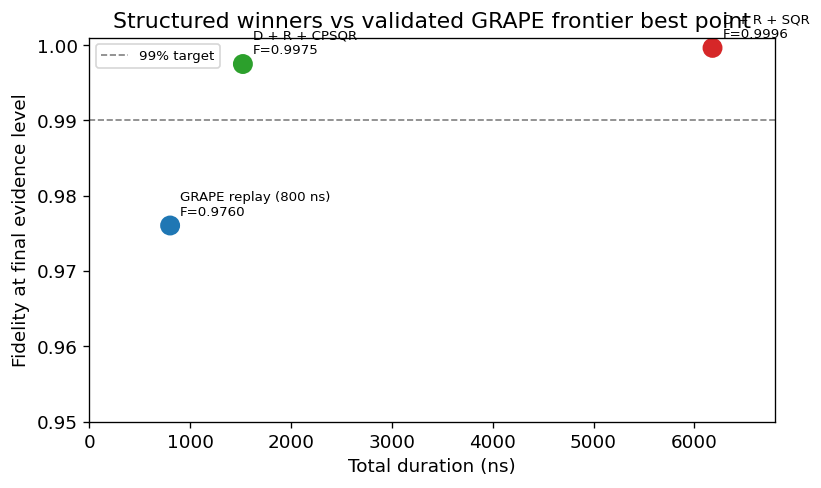

Saved to figures/notebook_structured_vs_grape.pdf


In [32]:
grape_label = f"GRAPE replay ({grape_reference['duration_ns']} ns)"
comparison_labels = ['D + R + SQR', 'D + R + CPSQR', grape_label]
comparison_f12 = [
    by_n_cav(final_sqr, NOTEBOOK_CONFIG['final_n_cav'])['fidelity'],
    by_n_cav(final_cpsqr, NOTEBOOK_CONFIG['final_n_cav'])['fidelity'],
    grape_reference['best_replay_fidelity'],
]
comparison_time = [
    final_sqr['summary']['total_duration_ns'],
    final_cpsqr['summary']['total_duration_ns'],
    grape_reference['duration_ns'],
]

print('Current validated GRAPE frontier reference')
print(f"  duration_ns     = {grape_reference['duration_ns']}")
print(f"  replay fidelity = {grape_reference['best_replay_fidelity']:.6f}")
print(f"  open fidelity   = {grape_reference['open_process']['process_fidelity']:.6f}")
print(f"  engine metadata = {describe_grape_engine(grape_reference)}")
print('  interpretation  = the explored durations and optimization settings did not yet reach 0.99 replay fidelity')

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(comparison_time, comparison_f12, s=120, color=['C3', 'C2', 'C0'])
for label, x, y in zip(comparison_labels, comparison_time, comparison_f12):
    ax.annotate(f'{label}\nF={y:.4f}', (x, y), textcoords='offset points', xytext=(6, 6), fontsize=8)
ax.set_xlabel('Total duration (ns)')
ax.set_ylabel('Fidelity at final evidence level')
ax.set_title('Structured winners vs validated GRAPE frontier best point')
ax.set_xlim(0, max(comparison_time) * 1.1)
ax.set_ylim(0.95, 1.001)
ax.axhline(NOTEBOOK_CONFIG['target_fidelity'], color='gray', ls='--', lw=1, label='99% target')
ax.legend(fontsize=8)
fig.tight_layout()
if NOTEBOOK_CONFIG['save_figures']:
    plt.savefig('../figures/notebook_structured_vs_grape.pdf', bbox_inches='tight')
plt.show()
if NOTEBOOK_CONFIG['save_figures']:
    print('Saved to figures/notebook_structured_vs_grape.pdf')

---
## 7. Primitive-Level GRAPE Diagnostics

This load-saved step pulls the representative SQR and CPSQR primitive diagnostics from `data/primitive_grape_diagnostics.json`, reports their joint-state and reduced-cavity fidelities on the saved probe set, and displays the saved summary/Wigner figures used in the report. It is controlled by `primitive_diagnostics_filename`, `primitive_arrays_filename`, `primitive_summary_figure`, `primitive_wigner_figure`, `primitive_engine_preference`, `primitive_seeds`, `primitive_maxiter`, and `rerun_primitive_diagnostics` from the tunable-parameter cell.

Primitive-diagnostics artifact
  summary path   = primitive_grape_diagnostics.json
  array path     = primitive_grape_diagnostics_arrays.npz
  summary figure = primitive_grape_summary.png
  wigner figure  = primitive_grape_wigner.png
  rerun engine   = jax
  seeds/maxiter  = (17, 42, 73) / 200

Representative SQR primitive
  retained block        = S0 from corrected_best_sqr.json
  addressed levels      = [0, 1, 2, 3]
  diagnostic levels     = [0, 1, 2, 3, 5]
  duration_ns           = 1100.0
  best seed / engine    = 17 / jax
  peak qubit drive (MHz)= 20.286
  subspace fidelity     = 0.695915
  mean joint fidelity   = 0.579336
  min joint fidelity    = 0.318561
  mean cavity fidelity  = 0.842850
  min cavity fidelity   = 0.763430
  worst probe           = |+>x(|0>+|1>+|2>+|3>)/2
  worst joint fidelity  = 0.577626
  worst cavity fidelity = 0.763430
    seed=17: subspace=0.695915, iterations=0, elapsed_s=4.11, message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    seed=42: subs

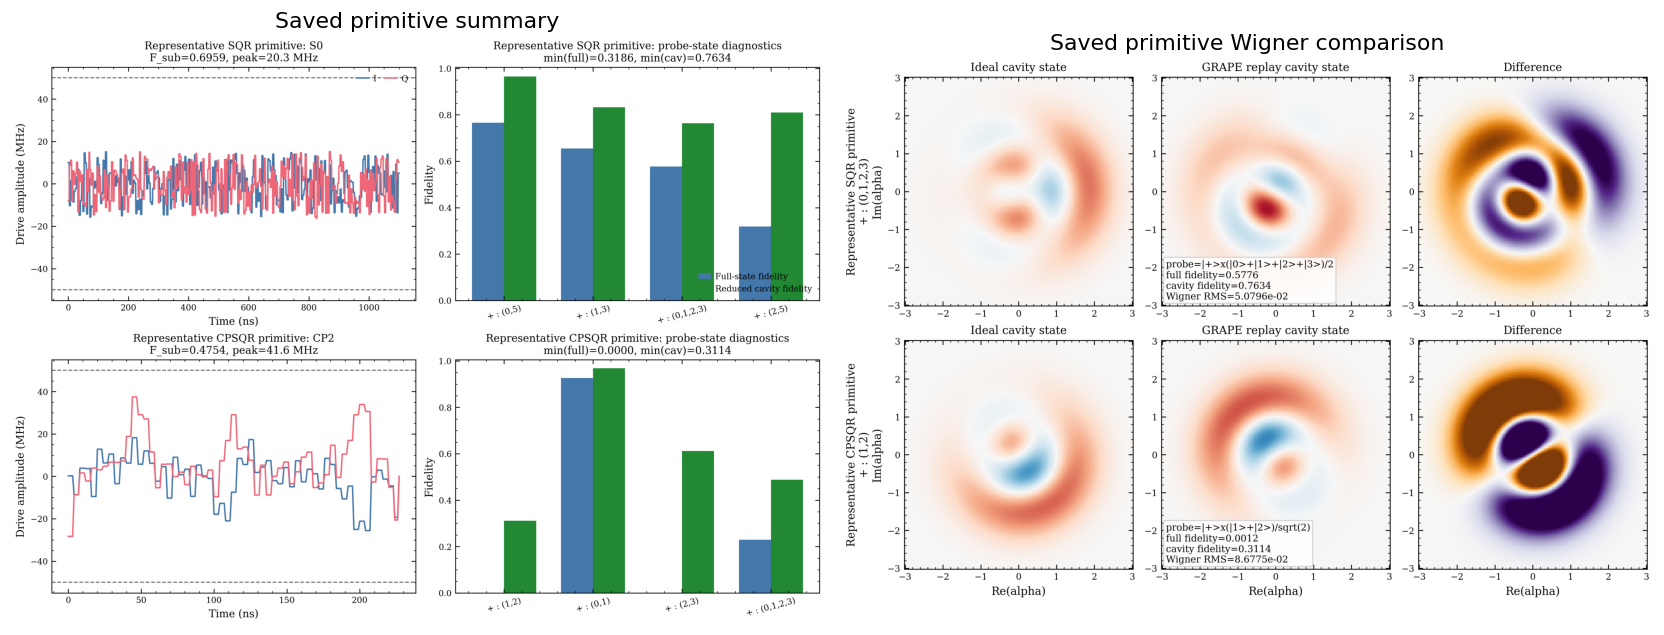

In [41]:
print("Primitive-diagnostics artifact")
print(f"  summary path   = {PRIMITIVE_DIAGNOSTICS_PATH.name}")
print(f"  array path     = {PRIMITIVE_ARRAYS_PATH.name}")
print(f"  summary figure = {PRIMITIVE_SUMMARY_FIG_PATH.name}")
print(f"  wigner figure  = {PRIMITIVE_WIGNER_FIG_PATH.name}")
print(f"  rerun engine   = {preferred_primitive_engine}")
print(f"  seeds/maxiter  = {NOTEBOOK_CONFIG['primitive_seeds']} / {NOTEBOOK_CONFIG['primitive_maxiter']}")
print()

def print_primitive_summary(label, payload):
    worst = payload["worst_probe"]
    print(label)
    print(f"  retained block        = {payload['gate_name']} from {payload['source_artifact']}")
    print(f"  addressed levels      = {payload['levels']}")
    print(f"  diagnostic levels     = {payload['diagnostic_levels']}")
    print(f"  duration_ns           = {payload['duration_ns']}")
    print(f"  best seed / engine    = {payload['best_seed']} / {payload['best_engine']}")
    print(f"  peak qubit drive (MHz)= {payload['peak_qubit_drive_mhz']:.3f}")
    print(f"  subspace fidelity     = {payload['best_validation_subspace_fidelity']:.6f}")
    print(f"  mean joint fidelity   = {payload['mean_full_state_fidelity']:.6f}")
    print(f"  min joint fidelity    = {payload['min_full_state_fidelity']:.6f}")
    print(f"  mean cavity fidelity  = {payload['mean_reduced_cavity_fidelity']:.6f}")
    print(f"  min cavity fidelity   = {payload['min_reduced_cavity_fidelity']:.6f}")
    print(f"  worst probe           = {worst['detail_label']}")
    print(f"  worst joint fidelity  = {worst['full_state_fidelity']:.6f}")
    print(f"  worst cavity fidelity = {worst['reduced_cavity_fidelity']:.6f}")
    for row in payload["seed_runs"]:
        print(
            f"    seed={row['seed']}: subspace={row['validation_subspace_fidelity']:.6f}, "
            f"iterations={row['iterations']}, elapsed_s={row['elapsed_s']:.2f}, "
            f"message={row['message']}"
        )
    print()

print_primitive_summary("Representative SQR primitive", primitive_sqr)
print_primitive_summary("Representative CPSQR primitive", primitive_cpsqr)

missing_paths = [
    path for path in (PRIMITIVE_SUMMARY_FIG_PATH, PRIMITIVE_WIGNER_FIG_PATH)
    if not path.exists()
 ]
if missing_paths:
    raise FileNotFoundError(f"Missing saved primitive figure(s): {missing_paths}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, path, title in [
    (axes[0], PRIMITIVE_SUMMARY_FIG_PATH, "Saved primitive summary"),
    (axes[1], PRIMITIVE_WIGNER_FIG_PATH, "Saved primitive Wigner comparison"),
]:
    ax.imshow(plt.imread(path))
    ax.axis("off")
    ax.set_title(title)
fig.tight_layout()
plt.show()

### Re-Run With Current Parameters

The cell below is intentionally commented out. Uncomment it only if you want to regenerate the representative primitive diagnostics with the current notebook parameters rather than loading the saved artifact bundle and saved report figures.

In [ ]:
# --- Re-run with current parameters ---
# from subprocess import run
# 
# primitive_args = [
#     sys.executable,
#     str(SCRIPTS_DIR / "run_primitive_grape_diagnostics.py"),
#     "--engine", NOTEBOOK_CONFIG["primitive_engine_preference"],
#     "--maxiter", str(NOTEBOOK_CONFIG["primitive_maxiter"]),
#     "--seeds",
#     *[str(seed) for seed in NOTEBOOK_CONFIG["primitive_seeds"]],
# ]
# if NOTEBOOK_CONFIG["rerun_primitive_diagnostics"]:
#     run(primitive_args, check=True, cwd=SCRIPTS_DIR)
# else:
#     print("Set NOTEBOOK_CONFIG['rerun_primitive_diagnostics'] = True to enable the expensive primitive rerun.")

---
## 8. Final Recommendation

This final load-saved cell states which family wins on the original full-target metric, which one wins on the reduced ground-sector metric, how both compare with the current best validated GRAPE replay point, and why the representative primitive-level GRAPE route is still diagnostic rather than hybrid-ready. It also regenerates the compact ranking plot and states the next search priorities for both objective branches.

=== Unified Final Recommendation ===

Full-target structured branch:
  - Best retained SQR winner   : F12 = 0.999635, leakage = 0.000777, order = RDS
  - Best retained CPSQR winner : F12 = 0.997492, leakage = 0.005423, order = DRCP

Ground-sector follow-up branch:
  - Best absolute SQR          : blocks = 5, F_ground = 0.999926, outside leakage = 0.000177
  - Best absolute CPSQR        : blocks = 4, F_ground = 0.999928, outside leakage = 0.000176
  - Minimum-depth SQR > 0.99   : blocks = 3, F_ground = 0.999745
  - Minimum-depth CPSQR > 0.99 : blocks = 3, F_ground = 0.997877

Objective mismatch diagnostic:
  - Old full-target SQR winner rescored on ground sector   : F_ground = 0.499201, ancilla excitation = 0.999843
  - Old full-target CPSQR winner rescored on ground sector : F_ground = 0.498720, ancilla excitation = 0.997676

Recommendation:
  - Choose D + R + SQR if the objective is the highest full-target closed-system structured fidelity.
  - Choose the 4-block D + R + CPSQR RDCP fo

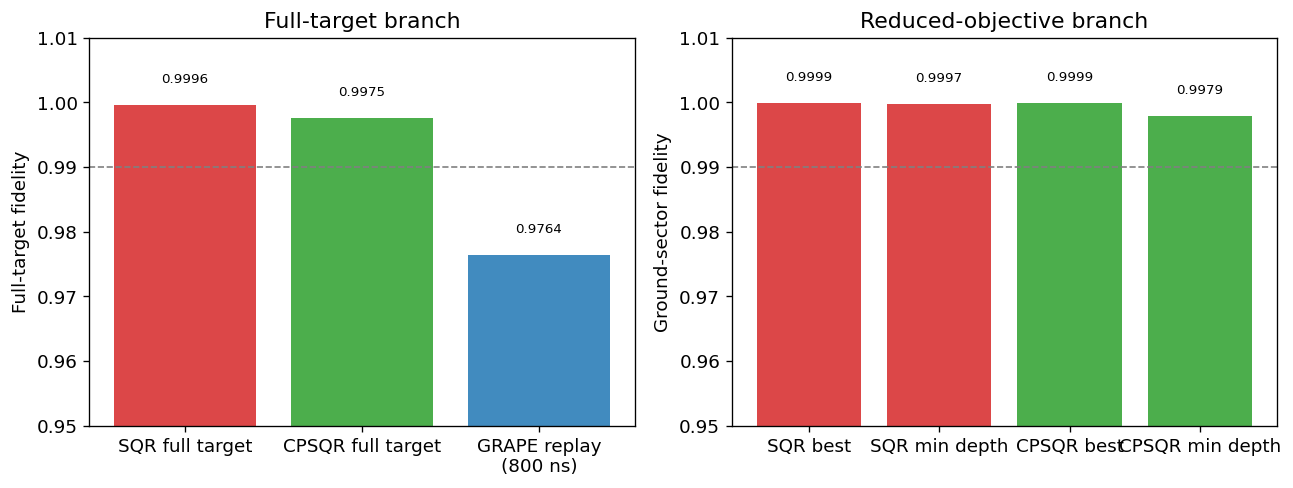

Saved to figures/notebook_final_ranking.pdf


In [5]:
print('=== Unified Final Recommendation ===')
print()
print('Full-target structured branch:')
print(f"  - Best retained SQR winner   : F12 = {by_n_cav(final_sqr, NOTEBOOK_CONFIG['final_n_cav'])['fidelity']:.6f}, leakage = {by_n_cav(final_sqr, NOTEBOOK_CONFIG['final_n_cav'])['leakage_worst']:.6f}, order = {final_sqr['summary']['order_label'] if 'order_label' in final_sqr['summary'] else final_sqr.get('order_label', 'RDS')}")
print(f"  - Best retained CPSQR winner : F12 = {by_n_cav(final_cpsqr, NOTEBOOK_CONFIG['final_n_cav'])['fidelity']:.6f}, leakage = {by_n_cav(final_cpsqr, NOTEBOOK_CONFIG['final_n_cav'])['leakage_worst']:.6f}, order = {final_cpsqr['summary']['order_label'] if 'order_label' in final_cpsqr['summary'] else final_cpsqr.get('order_label', 'DRCP')}")
print()
print('Ground-sector follow-up branch:')
print(f"  - Best absolute SQR          : blocks = {ground_best_sqr['blocks']}, F_ground = {ground_best_sqr['n12_ground_fidelity']:.6f}, outside leakage = {ground_best_sqr['outside_target_leakage_worst']:.6f}")
print(f"  - Best absolute CPSQR        : blocks = {ground_best_cpsqr['blocks']}, F_ground = {ground_best_cpsqr['n12_ground_fidelity']:.6f}, outside leakage = {ground_best_cpsqr['outside_target_leakage_worst']:.6f}")
print(f"  - Minimum-depth SQR > 0.99   : blocks = {ground_min_depth_sqr['blocks']}, F_ground = {ground_min_depth_sqr['n12_ground_fidelity']:.6f}")
print(f"  - Minimum-depth CPSQR > 0.99 : blocks = {ground_min_depth_cpsqr['blocks']}, F_ground = {ground_min_depth_cpsqr['n12_ground_fidelity']:.6f}")
print()
print('Objective mismatch diagnostic:')
print(f"  - Old full-target SQR winner rescored on ground sector   : F_ground = {baseline_old_sqr['n12_ground_fidelity']:.6f}, ancilla excitation = {baseline_old_sqr['ancilla_excitation_worst']:.6f}")
print(f"  - Old full-target CPSQR winner rescored on ground sector : F_ground = {baseline_old_cpsqr['n12_ground_fidelity']:.6f}, ancilla excitation = {baseline_old_cpsqr['ancilla_excitation_worst']:.6f}")
print()
print('Recommendation:')
print('  - Choose D + R + SQR if the objective is the highest full-target closed-system structured fidelity.')
print('  - Choose the 4-block D + R + CPSQR RDCP follow-up if the objective is the best reduced ground-sector transfer.')
print('  - Choose the 3-block reduced-target winners if minimum depth above the 0.99 ground-sector threshold is the primary metric.')
print(f"  - Choose the {grape_reference['duration_ns']} ns GRAPE reference if the priority is the fastest path with existing open-system validation.")
print(f"  - Current best validated GRAPE replay point: replay={grape_reference['best_replay_fidelity']:.6f}, open={grape_reference['open_process']['process_fidelity']:.6f}.")
print('  - Primitive GRAPE on representative retained blocks remains diagnostic only; it is still not accurate enough to replace the ideal structured blocks end-to-end.')
print(f"  - Primitive SQR diagnostic: F_sub={primitive_sqr['best_validation_subspace_fidelity']:.4f}, mean joint={primitive_sqr['mean_full_state_fidelity']:.4f}, mean cavity={primitive_sqr['mean_reduced_cavity_fidelity']:.4f}.")
print(f"  - Primitive CPSQR diagnostic: F_sub={primitive_cpsqr['best_validation_subspace_fidelity']:.4f}, mean joint={primitive_cpsqr['mean_full_state_fidelity']:.4f}, mean cavity={primitive_cpsqr['mean_reduced_cavity_fidelity']:.4f}.")
print('  - Next-stage priorities: fresh 2-block reduced-target searches and open-system validation of the reduced-target winners.')

full_target_labels = [
    'SQR full target',
    'CPSQR full target',
    f"GRAPE replay\n({grape_reference['duration_ns']} ns)",
]
full_target_values = [
    by_n_cav(final_sqr, NOTEBOOK_CONFIG['final_n_cav'])['fidelity'],
    by_n_cav(final_cpsqr, NOTEBOOK_CONFIG['final_n_cav'])['fidelity'],
    grape_reference['best_replay_fidelity'],
]

ground_labels = [
    'SQR best',
    'SQR min depth',
    'CPSQR best',
    'CPSQR min depth',
]
ground_values = [
    ground_best_sqr['n12_ground_fidelity'],
    ground_min_depth_sqr['n12_ground_fidelity'],
    ground_best_cpsqr['n12_ground_fidelity'],
    ground_min_depth_cpsqr['n12_ground_fidelity'],
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
bars_left = axes[0].bar(full_target_labels, full_target_values, color=['C3', 'C2', 'C0'], alpha=0.85)
axes[0].axhline(NOTEBOOK_CONFIG['target_fidelity'], color='gray', ls='--', lw=1)
axes[0].set_ylabel('Full-target fidelity')
axes[0].set_ylim(0.95, 1.01)
axes[0].set_title('Full-target branch')
for bar in bars_left:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)

bars_right = axes[1].bar(ground_labels, ground_values, color=['C3', 'C3', 'C2', 'C2'], alpha=0.85)
axes[1].axhline(NOTEBOOK_CONFIG['ground_target_threshold'], color='gray', ls='--', lw=1)
axes[1].set_ylabel('Ground-sector fidelity')
axes[1].set_ylim(0.95, 1.01)
axes[1].set_title('Reduced-objective branch')
for bar in bars_right:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)

fig.tight_layout()
if NOTEBOOK_CONFIG['save_figures']:
    plt.savefig('../figures/notebook_final_ranking.pdf', bbox_inches='tight')
plt.show()
if NOTEBOOK_CONFIG['save_figures']:
    print('Saved to figures/notebook_final_ranking.pdf')

## Final Summary

| Result | Value |
|---|---|
| Exclusive structured families | $D+R+\mathrm{SQR}$ and $D+R+\mathrm{CPSQR}$ only |
| Full-target branch | $U_{\mathrm{target}} = \mathrm{SWAP}\cdot\mathrm{CZ}\cdot(H\otimes I)$ on $\{|g,0\rangle, |g,1\rangle, |e,0\rangle, |e,1\rangle\}$ |
| Ground-sector branch | $U_{\mathrm{joint}}(|g\rangle \otimes |\psi\rangle) \approx |g\rangle \otimes H_c |\psi\rangle$ on $\{|g,0\rangle, |g,1\rangle\}$ |
| Search workflow | 216 structural screen cases, 30 level-subset refinements, 12 physical full-target finalists, plus 9 reduced-target block representatives |
| Final evidence rule | Use $N_{\mathrm{cav}}>8$, default $N_{\mathrm{cav}}=12$, with checks at $10,12,14$ |
| Active-subspace rule | Peak population threshold $10^{-3}$, expanded to capture at least $99.9\%$ |
| Best full-target SQR | 5 blocks, $n_{\mathrm{active}}=4$, order $RDS$, $F(N_{\mathrm{cav}}=12)=0.999635$, leakage $7.77\times 10^{-4}$, retained |
| Best full-target CPSQR | 5 blocks, $n_{\mathrm{active}}=2$, order $DRCP$, $F(N_{\mathrm{cav}}=12)=0.997492$, leakage $5.42\times 10^{-3}$, retained |
| Best reduced-target SQR | 5 blocks, $n_{\mathrm{active}}=4$, order $RDS$, $F_{\mathrm{ground}}(12)=0.999926$, outside-target leakage $1.77\times 10^{-4}$ |
| Minimum-depth reduced-target SQR above $0.99$ | 3 blocks, $n_{\mathrm{active}}=4$, order $RDS$, $F_{\mathrm{ground}}(12)=0.999745$ |
| Best reduced-target CPSQR | 4 blocks, $n_{\mathrm{active}}=4$, order $RDCP$, $F_{\mathrm{ground}}(12)=0.999928$, outside-target leakage $1.76\times 10^{-4}$ |
| Minimum-depth reduced-target CPSQR above $0.99$ | 3 blocks, $n_{\mathrm{active}}=3$, order $DRCP$, $F_{\mathrm{ground}}(12)=0.997877$ |
| Objective-mismatch diagnostic | The old full-target winners rescore to only about $0.50$ on the ground-sector metric because they excite the ancilla almost completely |
| Dominant design knob | Block count in both families; under the reduced target both families cross $0.99$ already at 3 blocks |
| GRAPE reference | Best complete validated frontier point: $F_{\mathrm{replay}}=0.9760$, $F_{\mathrm{open}}=0.9187$ at 800 ns; the explored settings did not yet reach 0.99 replay fidelity |
| Primitive GRAPE diagnostics | Representative SQR: $F_{\mathrm{sub}}=0.6959$, mean joint fidelity $0.5793$, mean reduced-cavity fidelity $0.8429$; representative CPSQR: $F_{\mathrm{sub}}=0.4754$, mean joint fidelity $0.2892$, mean reduced-cavity fidelity $0.5948$; informative only, not yet hybrid-ready |

### Parameter-Effect Table

| Parameter | Default | Effect on reproduced results |
|---|---|---|
| `summary_filename` | `corrected_scope_summary.json` | Selects which saved full-target structured-study summary is loaded |
| `what_changed_filename` | `what_changed_summary.md` | Selects the short revision summary displayed in the diagnostics section |
| `ground_followup_summary_filename` | `ground_sector_followup_summary.json` | Selects which saved reduced-objective summary is loaded |
| `ground_followup_candidates_filename` | `ground_sector_followup_candidates.csv` | Points to the flat candidate table for the reduced-objective section |
| `ground_best_sqr_artifact` | `ground_sector_best_sqr.json` | Selects the saved best reduced-target SQR artifact |
| `ground_best_cpsqr_artifact` | `ground_sector_best_cpsqr.json` | Selects the saved best reduced-target CPSQR artifact |
| `ground_block_figure` | `ground_sector_block_summary.png` | Identifies the saved report figure for the reduced-objective block comparison |
| `ground_scatter_figure` | `ground_sector_objective_scatter.png` | Identifies the saved report figure for the objective-mismatch comparison |
| `grape_frontier_filename` | `grape_frontier_extension.json` | Selects which validated GRAPE frontier artifact is used for the benchmark comparison |
| `primitive_diagnostics_filename` | `primitive_grape_diagnostics.json` | Selects the saved representative primitive-GRAPE summary loaded in the primitive diagnostics section |
| `primitive_arrays_filename` | `primitive_grape_diagnostics_arrays.npz` | Points to the saved waveform/Wigner array bundle in `artifacts/` that accompanies the primitive summary |
| `primitive_summary_figure` | `primitive_grape_summary.png` | Selects the saved primitive summary figure displayed in the notebook |
| `primitive_wigner_figure` | `primitive_grape_wigner.png` | Selects the saved reduced-cavity comparison figure displayed in the notebook |
| `grape_reference_selector` | `best-replay` | Chooses which complete frontier point is promoted to the notebook GRAPE reference |
| `grape_engine_preference` | `auto` | States which GRAPE engine should be preferred if the frontier is re-run from notebook-controlled settings |
| `primitive_engine_preference` | `auto` | States which engine should be preferred if the primitive diagnostics are re-run from notebook-controlled settings |
| `families` | `('drsqr', 'drcpsqr')` | Chooses which exclusive structured families are summarized and compared |
| `final_n_cav` | `12` | Sets the primary evidence truncation used in finalist metrics and plots |
| `validation_n_cav` | `(10, 12, 14)` | Controls which truncations are reported for convergence-style checks |
| `target_fidelity` | `0.99` | Sets the horizontal target line for the full-target branch figures |
| `ground_target_threshold` | `0.99` | Sets the horizontal target line for the reduced-objective branch figures |
| `leakage_reference` | `0.01` | Sets the leakage guide line in the full-target finalist leakage panel |
| `ground_refine_maxiter` | `16` | Controls the iteration cap used by the commented reduced-objective rerun cell |
| `primitive_seeds` | `(17, 42, 73)` | Controls which seeds are passed to the commented primitive rerun cell |
| `primitive_maxiter` | `200` | Controls the iteration cap used by the commented primitive rerun cell |
| `save_figures` | `True` | Controls whether regenerated notebook figures are written to `figures/` |
| `rerun_search` | `False` | When enabled in the commented rerun cell, re-executes the full structured design-space study |
| `rerun_figure_only` | `False` | When enabled together with the full-target rerun cell, regenerates figures using `--skip-search` |
| `rerun_ground_followup` | `False` | When enabled in the commented rerun cell, re-executes the reduced-objective follow-up |
| `rerun_ground_followup_skip_refine` | `False` | When enabled together with `rerun_ground_followup`, re-scores the stored block representatives without the local reduced-target refinement |
| `rerun_primitive_diagnostics` | `False` | When enabled in the commented primitive rerun cell, regenerates the representative primitive diagnostics |

**Unified recommendation**: choose $D+R+\mathrm{SQR}$ for the strongest full-target structured fidelity, choose the 4-block $D+R+\mathrm{CPSQR}$ follow-up for the strongest reduced ground-sector transfer, use the 3-block reduced-target winners when minimum depth above $0.99$ is the main criterion, keep the 800 ns GRAPE point as the only branch with existing open-system validation, and treat the next study priorities as fresh 2-block reduced-target searches plus open-system validation of the new reduced-target winners.

In [6]:
print('Unified reproducibility notebook complete.')
print(f'Loaded full-target summary from: {CORRECTED_SUMMARY_PATH}')
print(f'Loaded ground-sector follow-up from: {GROUND_FOLLOWUP_PATH}')
print(f'Loaded primitive diagnostics from: {PRIMITIVE_DIAGNOSTICS_PATH}')
print(f'Figures are available in: {FIG_DIR}')

Unified reproducibility notebook complete.
Loaded full-target summary from: C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\cluster_state_holographic_unified\data\corrected_scope_summary.json
Loaded ground-sector follow-up from: C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\cluster_state_holographic_unified\data\ground_sector_followup_summary.json
Loaded primitive diagnostics from: C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\cluster_state_holographic_unified\data\primitive_grape_diagnostics.json
Figures are available in: C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\cluster_state_holographic_unified\figures
